# Description:
Deduce $k$ empirically from the SNOTEL data

# Load analysis functions

In [ ]:
%run ...../imports.ipynb
%run ...../analysisScripts/snotelAnalysisFunctions.ipynb

## Additional functions

In [2]:
def subYear(datesForPlot):
    ''' Fix time coordinate for plotting so Sept-Dec are in the year prior'''
    for i,d in enumerate(datesForPlot):
        if datesForPlot[i].month>=10:
            datesForPlot[i] = datetime.datetime(1999, datesForPlot[i].month, datesForPlot[i].day, 0, 0)
    return datesForPlot

# Load data

add choice for loading all stations or just biased corrected stations...

In [3]:
stationBiasDict = loadTempBiasMarker()

In [4]:
rootPath = '...../snotelData/raw/'
stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']
metaData = loadStationMetaData()

In [5]:
allStateDict = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict[stateName] = stateDataCleaned

100%|██████████| 13/13 [00:14<00:00,  1.12s/it]


In [6]:
## Filter stations with the same functions used in other notebooks ##
allStateDict_filtered = filterStations(stateNames,allStateDict)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

# Average across water years for each station, then average stations

## $\left< k_\text{obs}(t) \right>$
Where the brackets indicate the mean/median/some other summary metric accross all stations

In [7]:
k_byStation = []
count = 0
for state in tqdm(stateNames):
    for station in allStateDict_filtered[state]:
        stationCopy = station.copy(deep=True)
        count += 1
        sweDiffs = stationCopy.swe.diff(dim='time')
        dd = stationCopy.T_avg
        dd_dayPrior = dd.copy(deep=True)
        dd_dayPrior['time'] = dd_dayPrior['time'] + np.timedelta64(1,'D')
        dd_dayPrior[dd_dayPrior<0] = 0
       
        # condition on days with SWE > 0
        sweDiffs = sweDiffs.where(stationCopy.swe[1:] > 0,drop=True)
        dd_dayPrior = dd_dayPrior.where(stationCopy.swe > 0,drop=True)
        
        # dont include SWE measurements where there was precipitation the day before, day of, or day after
        prcpDayPrior = stationCopy.prcp[1:].copy(deep=True)
        prcpDayOf = stationCopy.prcp[1:].copy(deep=True)
        prcpDayAfter = stationCopy.prcp[1:].copy(deep=True)

        tmp = stationCopy.prcp[:-1].values
        prcpDayPrior[:] = tmp

        tmp2 = stationCopy.prcp[1:].values
        prcpDayAfter[:] = tmp2

        precipExcludedInds = np.logical_and(np.logical_and(prcpDayPrior==0,prcpDayAfter==0),prcpDayOf==0)
        
        sweDiffs = sweDiffs.where(precipExcludedInds,drop=True)
        dd_dayPrior = dd_dayPrior.where(precipExcludedInds,drop=True)

        k = (-sweDiffs/dd_dayPrior)
        k[k==np.inf] = np.nan #0
        k[k<0] = np.nan #0

        kDayMean = k.groupby(k.time.dt.dayofyear).mean()
        
        k_byStation = k_byStation + [kDayMean]

100%|██████████| 13/13 [00:18<00:00,  1.41s/it]


In [8]:
print(f'Number of stations after filtering: {count}')

Number of stations after filtering: 506


In [13]:
## calculate either the mean, median, or histogram for each day of the year across all the stations ##
metricChoice = 'hist' # options: mean, median, hist

daysToAnalyze = np.arange(1,367)
if metricChoice == 'hist':
    dayMetric = []
else: 
    dayMetric = np.zeros(len(daysToAnalyze))
dayCounts = []
for i,d in enumerate(tqdm(daysToAnalyze)):
    daySum = 0
    dayKArray = np.array([])
    dayCount = 0
    for s in k_byStation:
        try:
            currK = s.sel(dayofyear=d).values
        except KeyError:
            currK = np.nan
        if not np.isnan(currK):
            if metricChoice == 'mean':
                daySum = daySum + currK
            elif metricChoice == 'median' or metricChoice == 'hist':
                dayKArray = np.append(dayKArray,currK)
            else:
                print('Not a valid metric!')
                break
            dayCount = dayCount + 1    
    if dayCount == 0:
        dayMetric[i] = np.nan
    else:
        if metricChoice == 'mean':
            dayMetric[i] = daySum/dayCount # note, dayCount==len(dayKArray) by design
        elif metricChoice == 'median':
            dayMetric[i] = np.median(dayKArray)
        elif metricChoice == 'hist':
            dayMetric = dayMetric + [dayKArray]
    dayCounts = dayCounts + [dayCount]

100%|██████████| 366/366 [00:07<00:00, 48.02it/s] 


In [14]:
# this code can only be run if metricChoice == 'mean' or 'median'
if metricChoice == 'median' or metricChoice == 'mean':
    fig = plt.figure()
    ax0 = plt.subplot(1,1,1)

    dates = np.array([datetime.datetime(2000, 1, 1) + datetime.timedelta(int(d) - 1) for d in daysToAnalyze])
    months = np.array([d.month for d in dates])
    waterYearInds = np.append(np.nonzero(months>=10)[0],np.nonzero(months<10)[0])
    datesForPlot = dates[waterYearInds]
    datesForPlot = subYear(datesForPlot)
    timeVaryK = dayMetric[waterYearInds]
    ax0.plot(datesForPlot,movingAverage(timeVaryK,1))
    ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90)
    ax0.tick_params(axis='x', labelrotation=45)
    ax0.set_xlim([min(datesForPlot),max(datesForPlot)])
    ax0.set_ylabel(r'Degree-day factor [mm $(\degree \text{C day})^{-1}$]')
    ax0.set_title(f'{metricChoice.capitalize()} degree-day factor across all stations')
    ax0.set_ylim([0,25])

In [15]:
## save the time-varying k for final figure ##
if metricChoice == 'median' or metricChoice == 'mean':
    saveBool = True
    if saveBool:
        np.save(f'....figureData/figureSupp_k{metricChoice}',timeVaryK)

## Histogram plot of k

In [17]:
# this code can only be run if metricChoice == 'hist'
if metricChoice == 'hist':
    binStep = .5
    binEdges = np.arange(-binStep/2,26+binStep/2,binStep)
    binCenters = (binEdges[:-1]+binEdges[1:])/2
    hist2d = np.zeros((len(binCenters),len(dayMetric)))
    for j,dData in enumerate(dayMetric):
        vals,dummy = np.histogram(dData,binEdges,density=True)
        hist2d[:,j] = vals
        
    dates = np.array([datetime.datetime(2000, 1, 1) + datetime.timedelta(int(d) - 1) for d in daysToAnalyze])
    months = np.array([d.month for d in dates])
    waterYearInds = np.append(np.nonzero(months>=10)[0],np.nonzero(months<10)[0])
    datesForPlot = dates[waterYearInds]
    datesForPlot = subYear(datesForPlot)
    
    hist2d = hist2d[:,waterYearInds]

/tmp/ipykernel_1728/3596740839.py:8: RuntimeWarning: divide by zero encountered in log
  ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap='magma')
/tmp/ipykernel_1728/3596740839.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)


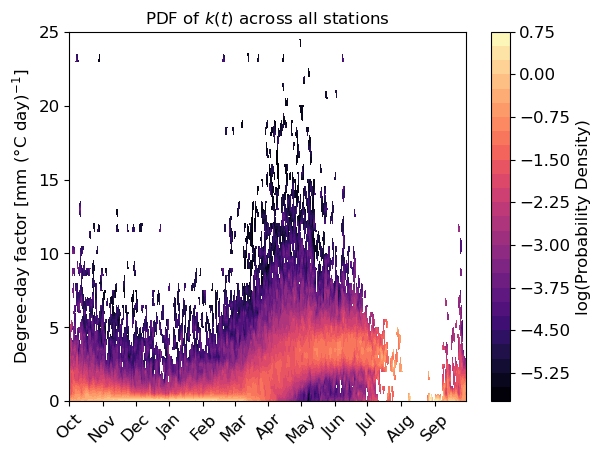

In [18]:
if metricChoice == 'hist':
    
    datedate,binbin = np.meshgrid(datesForPlot,binCenters)
    
    fig = plt.figure()
    ax0 = plt.subplot(1,1,1)
    figFontSize = 12
    ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap='magma')
    ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
    ax0.tick_params(axis='x', labelrotation=45)
    ax0.tick_params(axis='both', labelsize=figFontSize)
    cbar = plt.colorbar(ctf)
    cbar.ax.tick_params(labelsize=figFontSize)
    cbar.set_label(label='log(Probability Density)',fontsize=figFontSize)
    ax0.set_ylabel(r'Degree-day factor [mm $(\degree \text{C day})^{-1}$]',fontsize=figFontSize)
    ax0.set_ylim([0,25])
    ax0.set_title('PDF of $k(t)$ across all stations',fontsize=figFontSize)

    ## option to save the data for supplement figures ##
    saveBool = True
    if saveBool:
        pathToSave = '....../figureData'
        np.savez(pathToSave + '/figureSupp_k.npz', 
                 datesForPlot=datesForPlot,
                 binCenters = binCenters,
                 hist2d = hist2d)

## Number of stations contributing to each date

/tmp/ipykernel_1728/1741353771.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90)


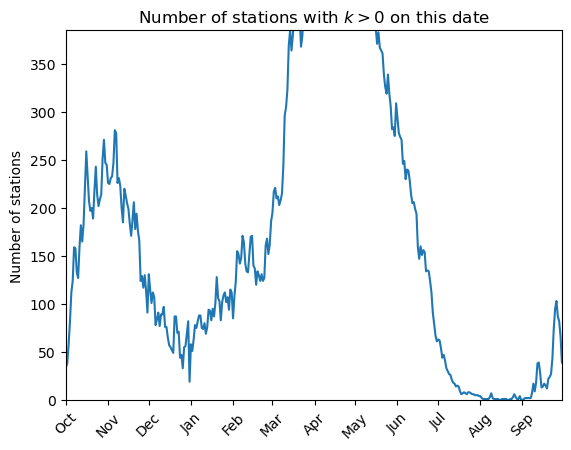

In [19]:
if metricChoice == 'hist':
    numberOfMeltyStations = np.array([])
    for ddata in dayMetric:
        numberOfMeltyStations = np.append(numberOfMeltyStations,sum(ddata>0))
    fig = plt.figure()
    ax0 = plt.subplot(1,1,1)
    dates = np.array([datetime.datetime(2000, 1, 1) + datetime.timedelta(int(d) - 1) for d in daysToAnalyze])
    ax0.plot(datesForPlot,numberOfMeltyStations[waterYearInds])
    ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90)
    ax0.tick_params(axis='x', labelrotation=45)
    ax0.set_xlim([min(datesForPlot),max(datesForPlot)])
    #ax0.set_ylim([0,850])
    ax0.set_ylabel(r'Number of stations')
    ax0.set_title(f'Number of stations with $k>0$ on this date')
    ax0.set_ylim([0,385])

    ## option to save the data for supplement figures ##
    saveBool = True
    if saveBool:
        pathToSave = '...../figureData'
        np.savez(pathToSave + '/figureSupp_kCount.npz', 
                 datesForPlot=datesForPlot,
                 numberOfMeltyStations = numberOfMeltyStations[waterYearInds]
                 )